# HackAI 2026 | Unsupervised LSTM Autoencoder for Jet Engine Fault Detection (With Attention Additions)

Neil Ghugare, Nishanth Kunchala, and Jacob Balek


**Important distinction! From here on out, the term "failure" refers to the official failure of the engine, where it can no longer function properly. The term "fault" refers to the point where the engine first develops a fault, but is still able to run until eventually reaching failure.**

### Imports and Data Fetching

This is a modification of the optimal model for FD001.

In [134]:
import tensorflow as tf
import numpy as np
import random
import os

# Set all random seeds for reproducibility
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

In [135]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization
from scipy.stats import spearmanr

%matplotlib inline

In [136]:
# Boolean that can be toggled on/off to do training in the notebook
training = True

We set a random seed to ensure reproducible results with Tensorflow randomization and weight-setting. We then fetch the data using KaggleHub via KaggleAPI and then read it into the standard Pandas `DataFrame`.

In [137]:
tf.random.set_seed(42)

In [138]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

We utilize the data's [README](https://www.kaggle.com/datasets/palbha/cmapss-jet-engine-simulated-data?select=readme.txt) to see that our columns will be the unit (which engine number), the cycle, then three operational settings (defining what regime the plane flew in like Mach speed), and then multiple sensor measurements.

In [139]:
col_names = ['Unit', 'Cycle Time', 'Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [140]:
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,...,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


### Exploratory Data Analysis

The following code outputs the data into a text file with a nice Markdown-style format so we can actually see the `describe` results (because it is hard to see or read in the cell output).

In [141]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read due to many sensors

Now we will use Seaborn to examine the operational settings and the sensor data. In this first plot, we will look at all of them as a function of the cycle time.

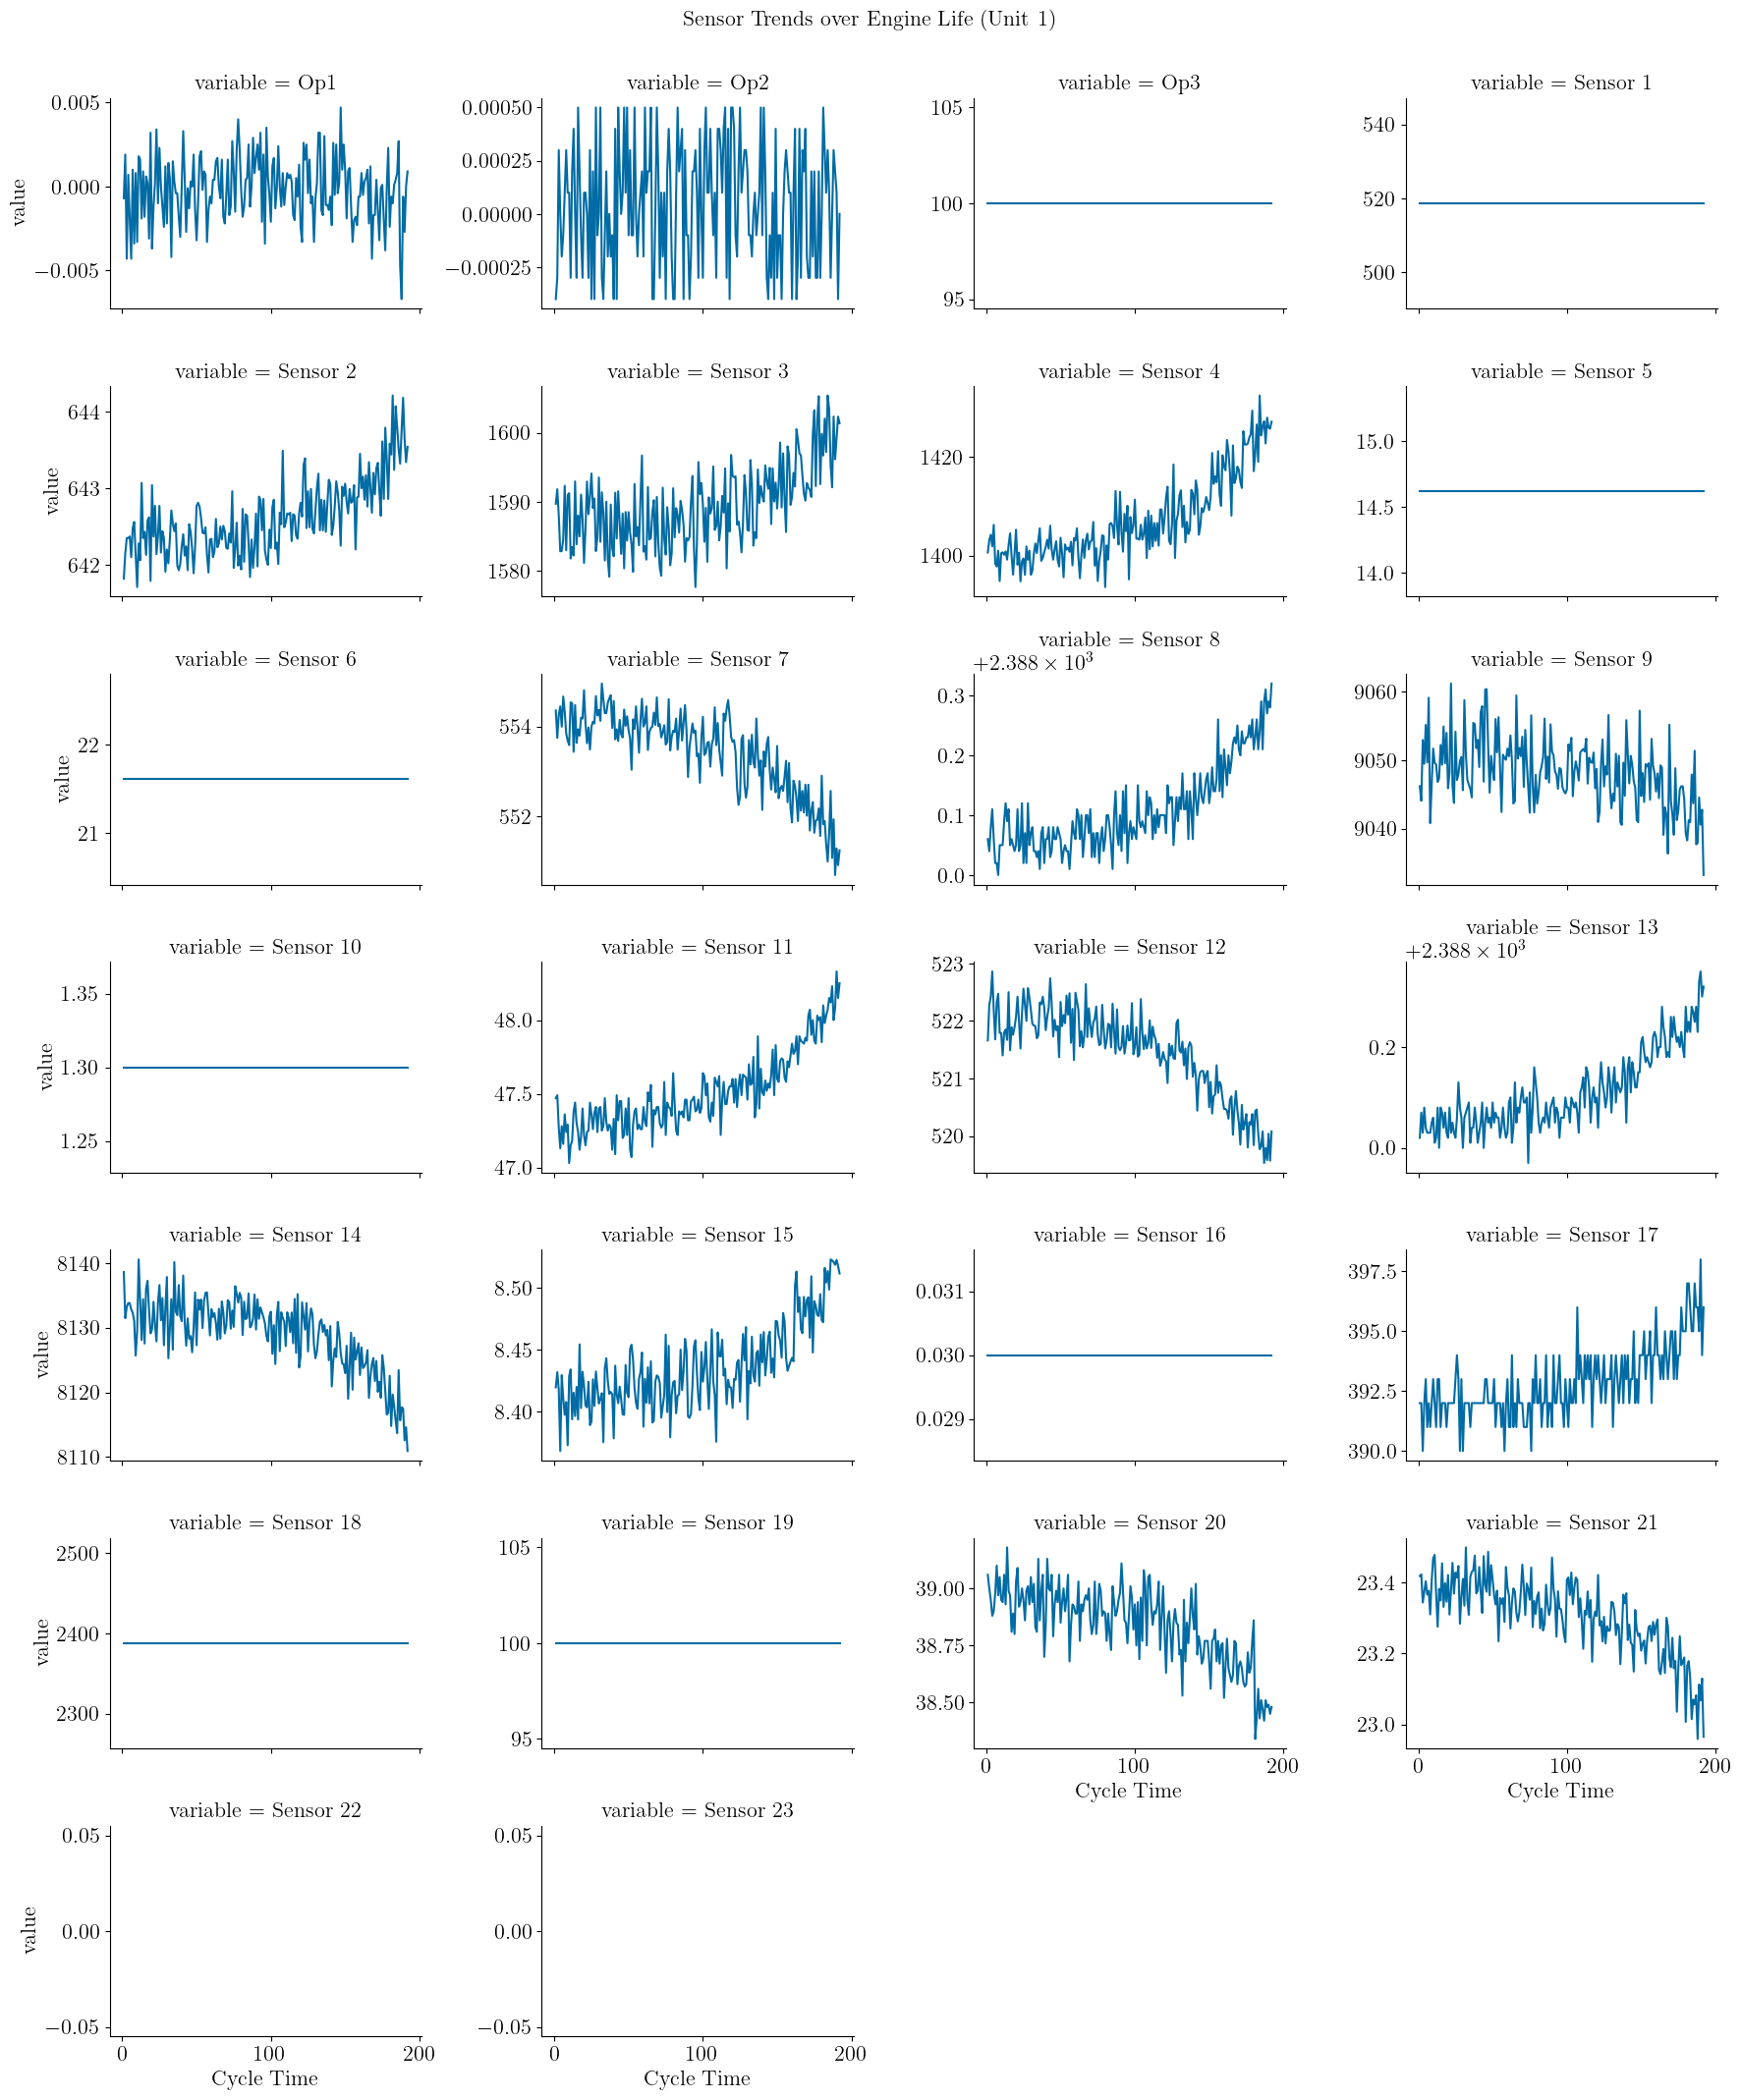

In [142]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=['Op1', 'Op2', 'Op3'] + [f'Sensor {_+1}' for _ in range(23)])
plt.show()

From the above plot, any sensor that is flat is either not in use or does not change during the lifetime of the engine. Those are unnecessary columns for the autoencoder to reconstruct, and thus we can safely drop them. In general, we don't want to drop the operational settings, but since the third one is constant, we *do* elect to drop that one.

In [143]:
cols_to_drop = ['Sensor 1', 'Sensor 5', 'Sensor 6', 'Sensor 10', 'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Sensor 22', 'Sensor 23']
relevant_sensors = [f'Sensor {_+1}' for _ in range(23) if _ not in (0, 4, 5, 9, 15, 16, 17, 18, 21, 22)]
ops = ['Op1', 'Op2']
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Op1,Op2,Op3,Sensor 2,Sensor 3,Sensor 4,Sensor 7,Sensor 8,Sensor 9,Sensor 11,Sensor 12,Sensor 13,Sensor 14,Sensor 15,Sensor 20,Sensor 21
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044


Now when we make the Seaborn plot, we will see only the variables that have significant impacts on the failure and fault.

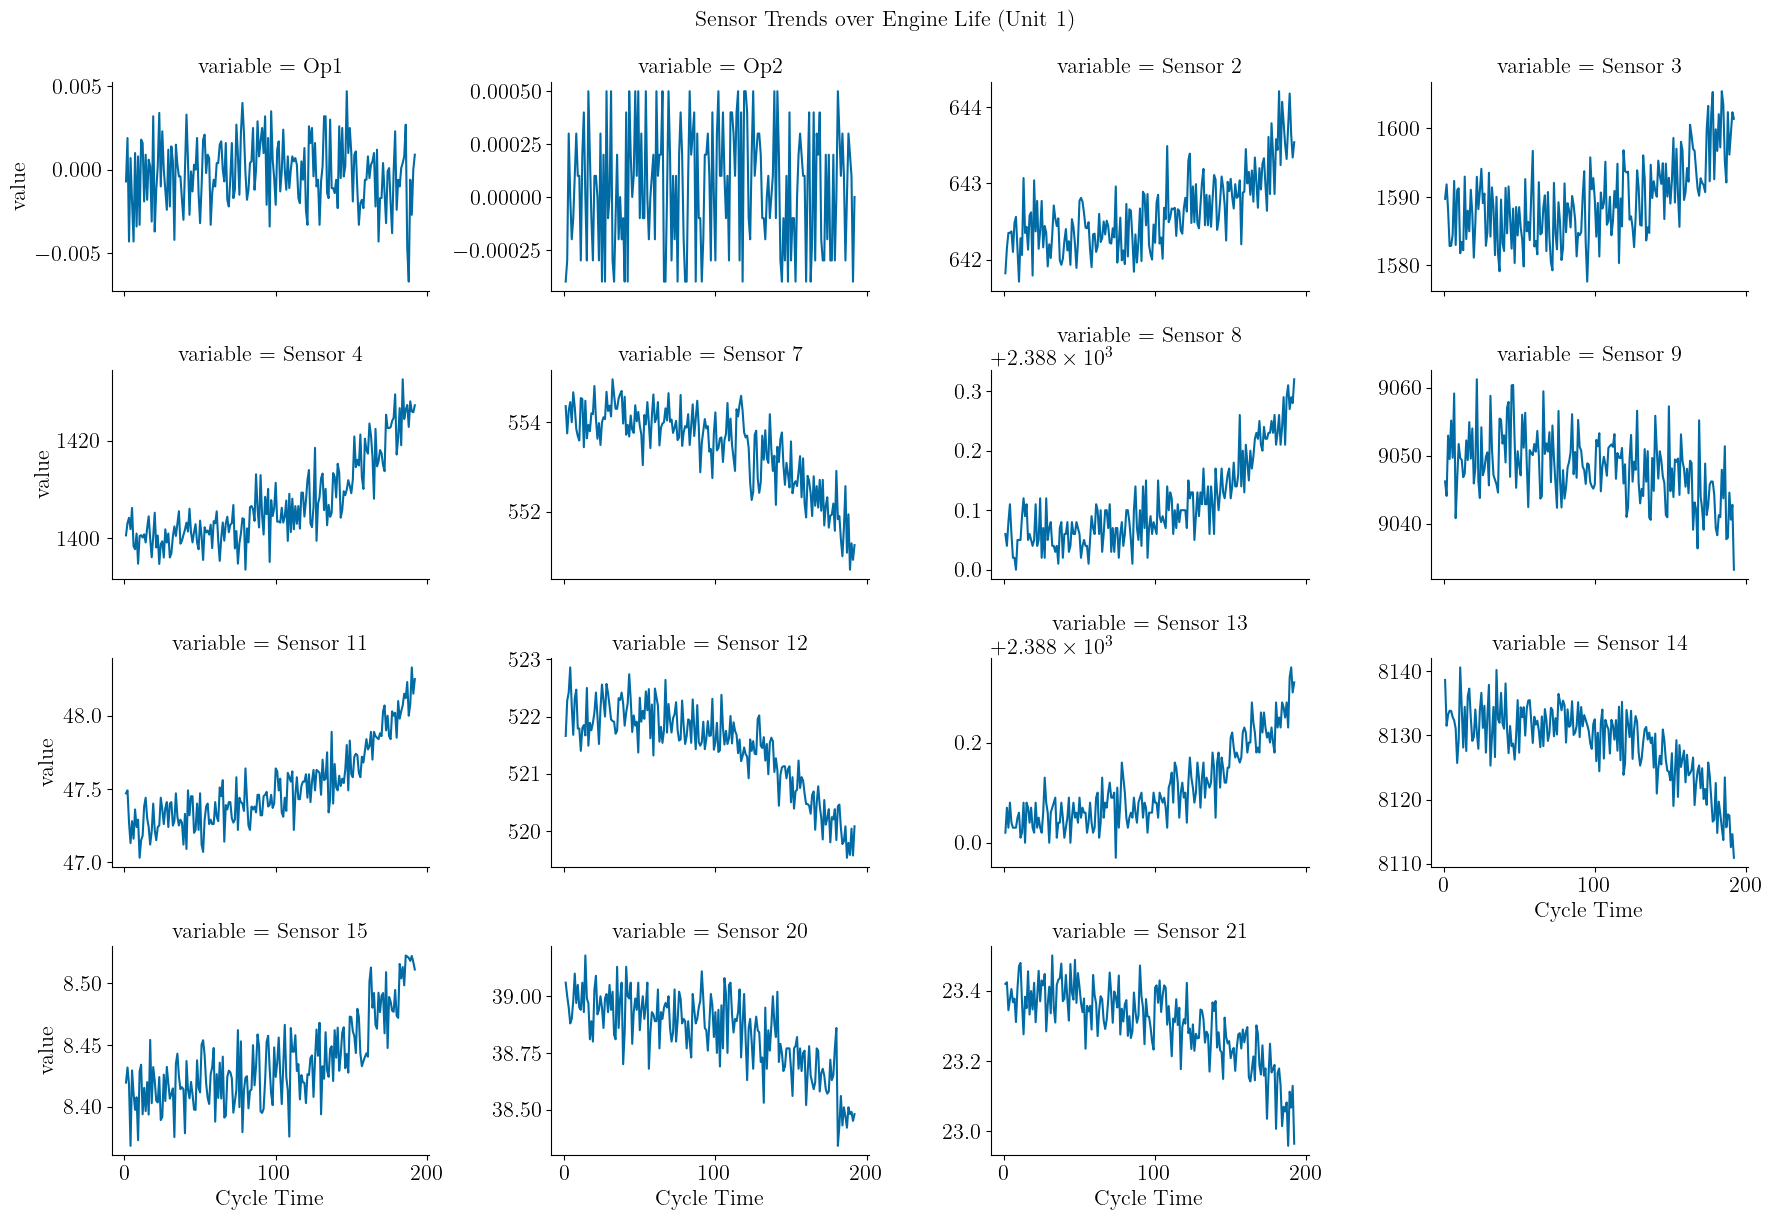

In [144]:
fig = sensor_explore_plot(df, ids='Cycle Time', values=ops+relevant_sensors)
plt.show()

One thing we wish to define is the *window size*, how many cycles the autoencoder will look at durign one reconstruction. We set this value to 50. We then use `MinMaxScaler` to normalize the data set for better usage.

In [145]:
wsize = 50 # Changed from 50, 12 seems better

# Fit ONLY on the first 50 cycles of the training data 
# This defines the 0.0 to 1.0 range based on HEALTHY engines
scaler = MinMaxScaler()
scaler.fit(df.groupby('Unit').head(wsize)[ops + relevant_sensors])

# Transform everything using that "Healthy Range"
df[ops + relevant_sensors] = scaler.transform(df[ops + relevant_sensors])
df_test[ops + relevant_sensors] = scaler.transform(df_test[ops + relevant_sensors])

We generate the train and test sets. See the `helper.py` file for the definitions and doc comments for these functions (and many more functions in this file). One important distinction is that we separate the operational settings from the sensors. In doing so, our data will have the operation settings inputted into the model, but will only output sensor data. Remember that the operational settings are things like altitude or Mach speed. It is not important for our autoencoder to reconstruct these as they have no direct relation to fault detection; They are just the current setting of a flight. 

In [146]:
X_train, Y_train = gen_train_windows_multi(df, wsize, ops, relevant_sensors)
X_test, Y_test, test_units = gen_test_windows_multi(df_test, wsize, ops, relevant_sensors)

From the shape, we can directly see this separation. The input (`X_train`) has a final column value of 15, which accounts for the 13 sensors plus 2 operational settings. The output only has 13, which accounts for the reconstruction of the 13 sensors (we don't care about reconstructing the operational settings).

In [147]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(100, 50, 15)
(100, 50, 13)
(93, 50, 15)
(93, 50, 13)


### Model

Now we move on to building the model utilizing Tensorflow's functional API. We create an LSTM autoencoder, taking the operational settings and relevant sensors as input. We apply an LSTM encodation the the data, bottlenecking it to force feature extraction with `RepeatVector` and then decoding it with an LSTM later.  

In [148]:
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Attention, Concatenate, Reshape, Multiply, GlobalAveragePooling1D
from tensorflow.keras.models import Model
import tensorflow.keras as keras

# Define dimensions based relevant lists
n_inputs = len(ops) + len(relevant_sensors)  # Total features in X_train
n_targets = len(relevant_sensors)            # Only the sensors in Y_train

# 1. Input Layer
# Matches the shape (window_size, total_features)
inputs = Input(shape=(wsize, n_inputs))

# ~~~~~~~~~~~~~~~
# Feature Attention

# 1. Compress time to get a summary of each sensor's activity
avg_pool = GlobalAveragePooling1D()(inputs) 
# 2. Learn a weight (0 to 1) for each sensor using Softmax
# These are your "Feature Importance" scores
feature_weights = Dense(n_inputs, activation='softmax', name='feature_weights')(avg_pool)

feature_weights_reshaped = Reshape((1, n_inputs))(feature_weights)
weighted_inputs = Multiply()([inputs, feature_weights_reshaped])
# ~~~~~~~~~~~~~~~

# 2. Encoder
# Processes both Ops and Sensors to find the 'hidden' health state
# encoder = LSTM(64, activation='tanh', return_sequences=False)(weighted_inputs)
encoder, state_h, state_c = LSTM(64, activation='tanh', return_sequences=True, return_state=True)(weighted_inputs)

# 3. Bottleneck
# Bridges the single 'thought vector' back into a sequence
bottleneck = RepeatVector(wsize)(state_h)

# 4. Decoder
decoder = LSTM(64, activation='tanh', return_sequences=True)(bottleneck)

# ~~~~~~~~~~~~~~~
# Temporal Attention

# 4. Temporal Attention
attention_results = Attention()([decoder, encoder], return_attention_scores=True)
context_vector = attention_results[0]
temporal_attention_scores = attention_results[1]
# ~~~~~~~~~~~~~~~

# 5. Output Layer
# This MUST match n_targets so it only reconstructs the relevant sensors
combined_features = Concatenate(axis=-1)([decoder, context_vector])
outputs = TimeDistributed(Dense(n_targets))(combined_features)

# ~~~~~~~~~~~~~~~
# Create Models

# Training Model

train_model = Model(inputs=inputs, outputs=outputs, name="training_model")
# Inference Model
inference_model = keras.models.Model(
    inputs=inputs, 
    outputs=[outputs, temporal_attention_scores, feature_weights], 
    name="inference_model"
)
# ~~~~~~~~~~~~~~~



# Compile

train_model.compile(optimizer='adam', loss='mae')
inference_model.compile(optimizer='adam', loss='mae')

train_model.summary()

Model: "training_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 50, 15)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 15)        │          0 │ input_layer_6[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_weights     │ (None, 15)        │        240 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (None, 1, 15)     │          0 │ feature_weights[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 50, 15)    │          0 │ input_layer_6[0]… │
│ (Multiply)          │                   │            │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ [(None, 50, 64),  │     20,480 │ multiply_6[0][0]  │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_6     │ (None, 50, 64)    │          0 │ lstm_12[0][1]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 50, 64)    │     33,024 │ repeat_vector_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_6         │ [(None, 50, 64),  │          0 │ lstm_13[0][0],    │
│ (Attention)         │ (None, 50, 50)]   │            │ lstm_12[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 50, 128)   │          0 │ lstm_13[0][0],    │
│ (Concatenate)       │                   │            │ attention_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 50, 13)    │      1,677 │ concatenate_6[0]… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,421 (216.49 KB)

 Trainable params: 55,421 (216.49 KB)

 Non-trainable params: 0 (0.00 B)

We now train the model. We utilize `EarlyStopping` and `ModelCheckpoint` callbacks to get the best possible results from our training step.

In [149]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_attention_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = train_model.fit(
        X_train, Y_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - loss: 0.4939 - val_loss: 0.4716
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4595 - val_loss: 0.4271
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4039 - val_loss: 0.3380
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2987 - val_loss: 0.2379
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2480 - val_loss: 0.2207
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2021 - val_loss: 0.1629
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1691 - val_loss: 0.1596
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1587 - val_loss: 0.1464
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1512 - val_loss: 0.1535
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1500 - val_loss: 0.1431
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.1437 - val_loss: 0.1422
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1417 - val_loss: 0.1364


We now make the necessary loss vs. epoch plot. From this, we get a good general shape.

In [150]:
# Run attention model outputs

# Now predict returns 3 items
results = inference_model.predict(X_test)
predictions = results[0]
temp_weights = results[1]  # Heatmap data (Time)
feat_weights = results[2]  # Bar chart data (Sensors)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/stepWARNING:tensorflow:5 out of the last 136 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x38bacfa60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


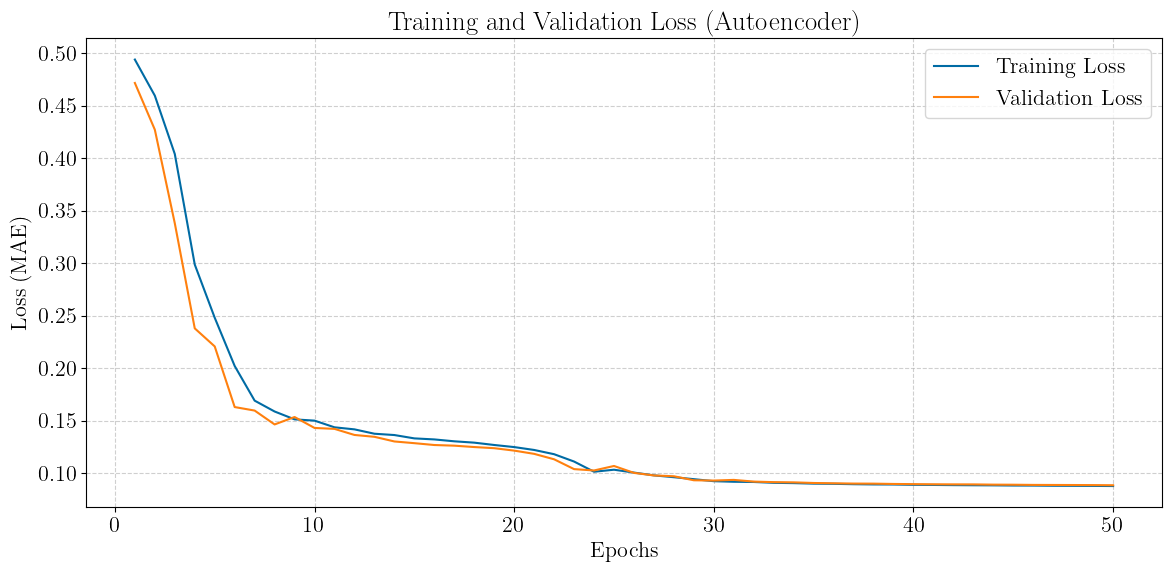

In [151]:
if training:
    fig = make_loss_plot(history)
    plt.show()

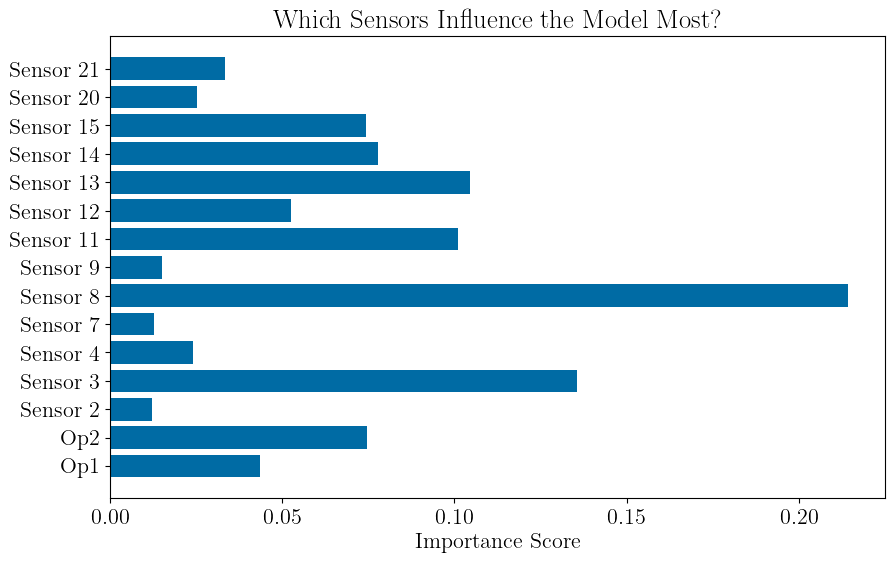

In [152]:
import matplotlib.pyplot as plt

# names = ['sensor1', 'sensor2', 'op_setting1', ...]
avg_feat_importance = feat_weights.mean(axis=0)

names = ["Op1", "Op2"] + relevant_sensors

plt.figure(figsize=(10, 6))
plt.barh(names, avg_feat_importance)
plt.title("Which Sensors Influence the Model Most?")
plt.xlabel("Importance Score")
plt.show()

In [153]:
print(avg_feat_importance)
avg_feat_importance.sum()

[0.04345281 0.07465449 0.01207102 0.13553984 0.02392226 0.01259071
 0.21437429 0.01512203 0.10103986 0.05242194 0.1044384  0.07773773
 0.07418554 0.02517151 0.03327756]


1.0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


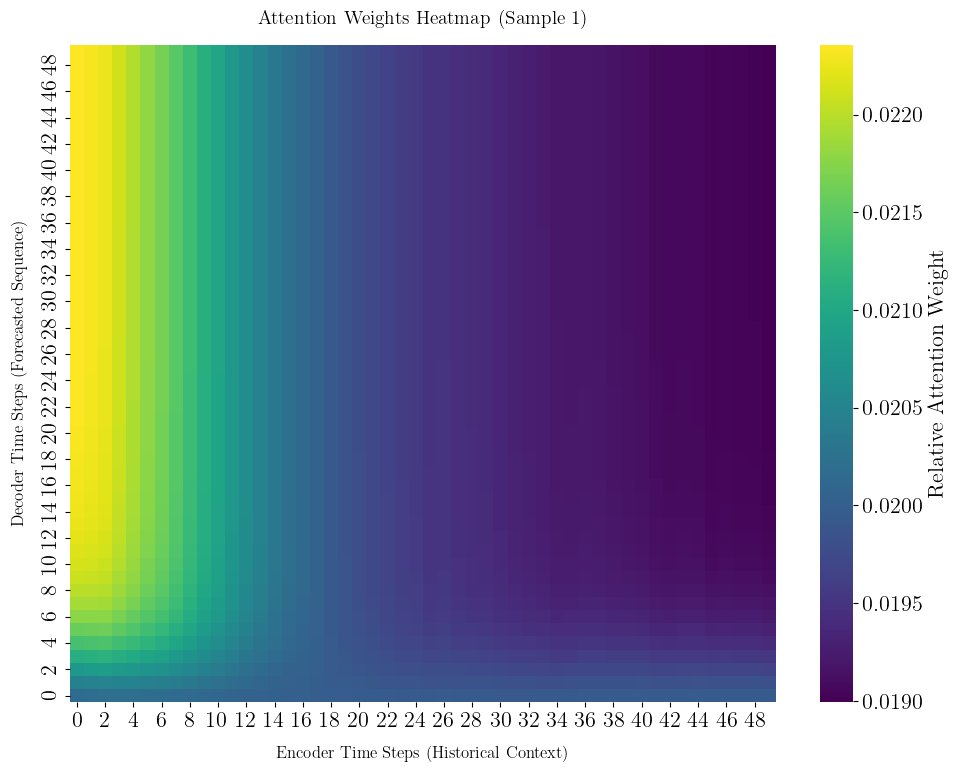

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention_heatmap(inference_model, x_data, sample_idx=0):
    """
    Generates predictions and plots the attention heatmap for a specific sample.
    """
    # 1. Run inference to get predictions and attention weights
    # inference_model outputs: [predictions (batch, wsize, targets), weights (batch, wsize, wsize)]
    results = inference_model.predict(x_data)
    all_attention_weights = results[1]
    
    # 2. Extract the 2D attention matrix for the requested sample
    attention_matrix = all_attention_weights[sample_idx]
    
    # 3. Set up the plot
    plt.figure(figsize=(10, 8))
    
    # Draw the heatmap
    # 'viridis' or 'magma' are excellent colormaps for highlighting focus areas
    # Change this part of your plotting function:
    ax = sns.heatmap(
        attention_matrix, 
        cmap="viridis",
        # vmin=0.0,  <-- DELETE THIS
        # vmax=1.0,  <-- DELETE THIS
        cbar_kws={'label': 'Relative Attention Weight'}
    )
    
    # 4. Configure labels
    plt.title(f"Attention Weights Heatmap (Sample {sample_idx})", fontsize=14, pad=15)
    plt.xlabel("Encoder Time Steps (Historical Context)", fontsize=12, labelpad=10)
    plt.ylabel("Decoder Time Steps (Forecasted Sequence)", fontsize=12, labelpad=10)
    
    # Invert the Y-axis so time step 0 is at the top left
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Example Usage
# ==========================================
# Assuming X_test is your sliding window test data
# Let's visualize the very first sequence in your test set
plot_attention_heatmap(inference_model, X_train, sample_idx=1)

We load the best model from the model checkpoint to use from here on out.

In [155]:
model = keras.models.load_model('best_model_attention_fd001.keras')

Now we can define the threshold of being above the 97.5th percentile above this mean ground error from reconstruction. We do *not* define this as 2 standard deviations because our error is not likely to be Gaussian distributed (usually having a longer tail). Doing a percentile method keeps everything consistent, regardless of distribution type. From this, we get our quiet failure threshold.

In [156]:
Y_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(Y_train_pred - Y_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.percentile(train_mae_loss, 97.5)

print(f"Quiet Failure Threshold: {threshold}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Quiet Failure Threshold: 0.09948741729797742


Below is a plot of the distribution of the train set's MAE loss per window as a function of the window's reconstruction error. We see where the threshold lies. The point of this distribution is to show that most of the reconstruction error is around the mean/median, and not having a mean due to large amounts of windows with low reconstruction error and high reconstruction error cancelling each other out.

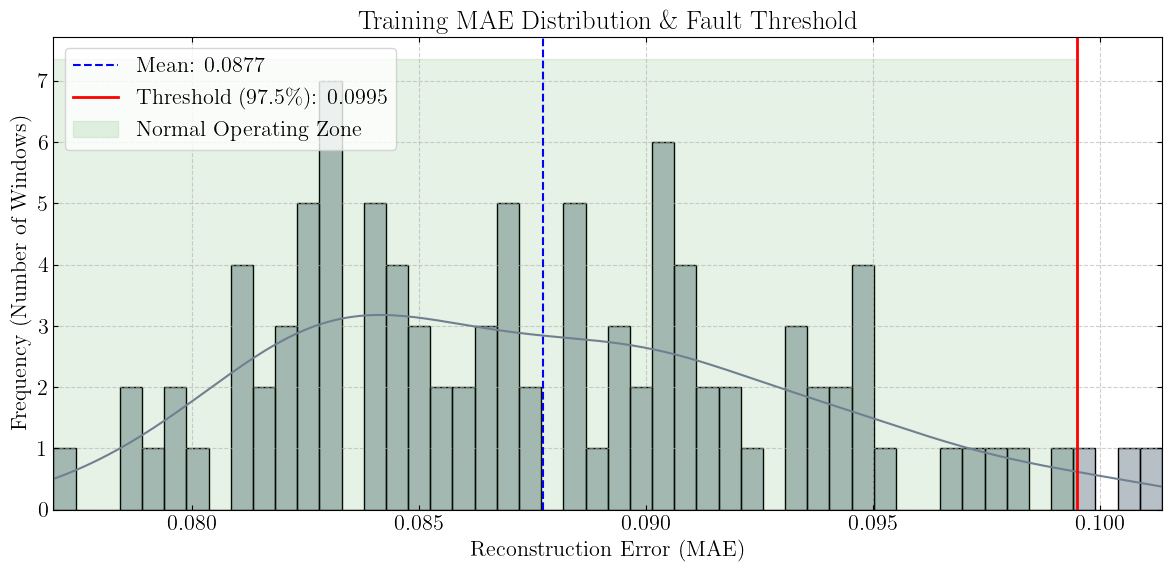

In [157]:
fig = plot_threshold_justification(train_mae_loss, threshold)
plt.show()

We can now predict if an engine fault has occurred by seeing if the test MAE loss ever crosses the threshold over cycle time. From the output of `is_failing`, we can pick some options and see if they do indeed develop a fault. Remember, failure here is engine stopping its functionality entirely. So, saying "is failing", doesn't mean "engine failed", it more means "fault detected".

In [158]:
Y_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(Y_test_pred - Y_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [159]:
print(is_failing)

[False False False False False False False False False  True False False
 False  True  True False  True  True False  True False False False  True
 False  True  True  True  True  True  True  True  True  True  True  True
 False False  True  True False False  True False False  True  True False
 False  True False False False False  True  True False  True False  True
 False  True False False False  True False False False  True False False
 False  True  True  True False False  True False False False  True  True
  True  True  True False False  True  True False  True]


From this output, we would anticipate unit 3 to not have any fault detected, but unit 17 to have a fault detected (which is indeed what we get).

In [160]:
anomaly_score = failure_detection(df_test, model, 3, threshold, wsize, ops, relevant_sensors)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
No Failure detected above threshold.


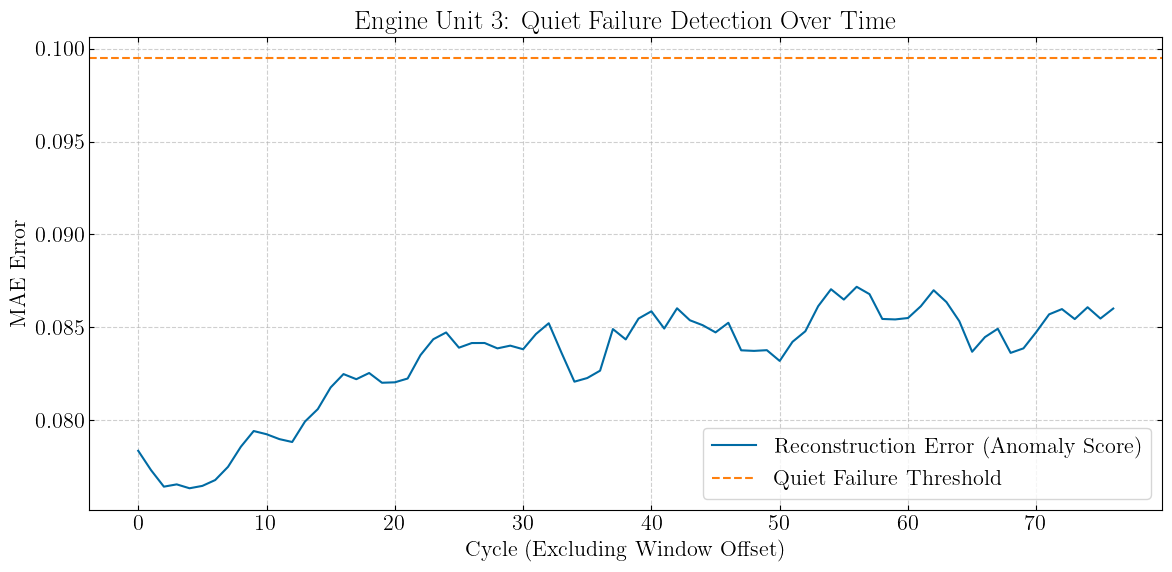

In [161]:
fig = failure_plot(anomaly_score, threshold, unit_no=3)
plt.show()

In [162]:
anomaly_score = failure_detection(df_test, model, 17, threshold, wsize, ops, relevant_sensors)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Quiet Failure detected at Cycle: 46


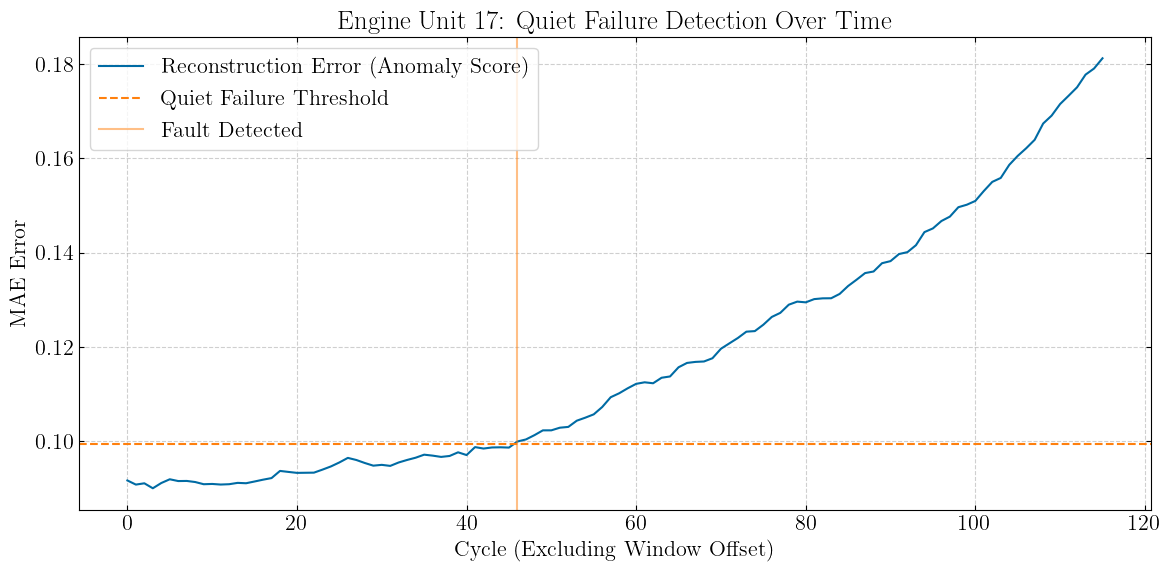

In [163]:
fig = failure_plot(anomaly_score, threshold, unit_no=17)
plt.show()

This is unsupervised, so we have no way of actually knowing if the fault has indeed occurred at the point identified. There is a way, however, we can be relatively certain quantitatively the our model is doing a good job. The test data has known RUL values, or Remaining Useful Life, which is the amount of cycles the test engine has left *at the end of the test data* (i.e. an RUL of 8 means 8 cycles after the end of the data, the machine should fail). 

We can then first qualitatively judge how good our model is. The maximum anomaly score MAE should be higher for engines with small RUL values (they are close to failing). Engines with high RUL values (long time until they fail) should have low anomaly scores. This relationship may not necessarily be linear. We do this with the `generate_audit_results` and `anomaly_rul_plot`.

In [ ]:
rul_truth = pd.read_csv(os.path.join(path, 'RUL_FD001.txt'), header=None).values.flatten()

audit_df = generate_audit_results(df_test, rul_truth, model, wsize, ops, relevant_sensors)

print("Top 10 Engines with Highest Anomaly Scores:")
audit_df.head(10)

0.0788349261398583 0.03149947470238716 0.08273693790269705


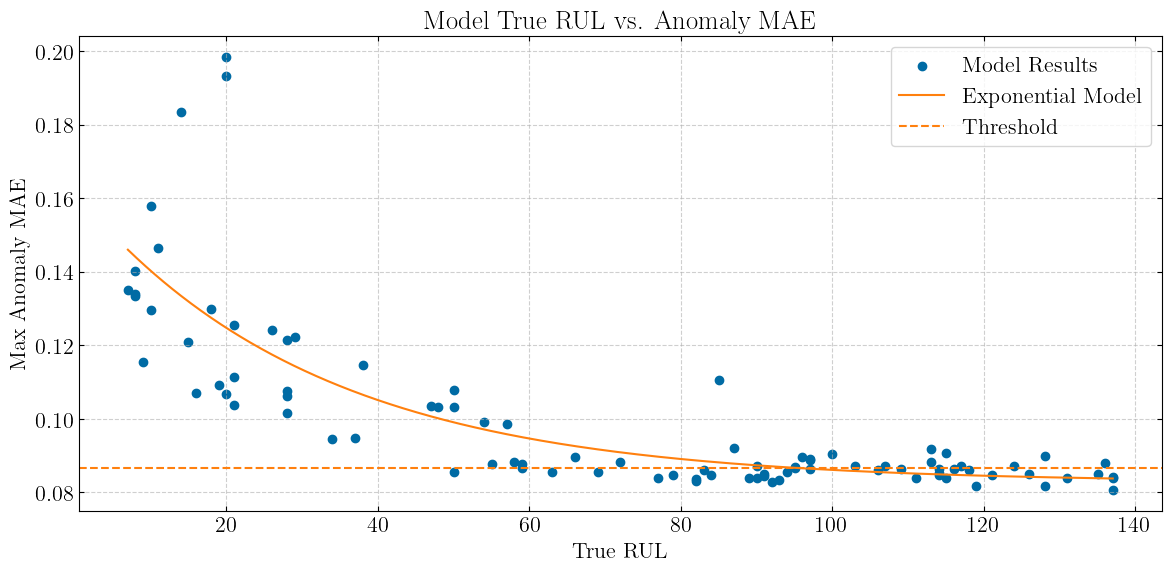

In [ ]:
fig = anomaly_rul_plot(audit_df, threshold)
plt.show()

We can see in general we get the expected result, that the MAE decreases with increasing RUL. We also see the increase in number of points below the threshold as we increase the true RUL. This is exactly the qualitative result we would expect.

Now we can put a quantitative measurement to this using the [Spearman correlation](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient). This correlation is like a standard (Pearson) correlation, which checks for a straight line relationship. Spearman checks if one variable goes up when the other goes down, regardless of whether that relationship is curved/exponential/etc. It is given by the formula:
$$
r_{\rm S} = 1 - \frac{6 \sum_i d^2_i}{n(n^2-1)},
$$
where $d_i$ is the difference between the rank of the $i^{\rm th}$ anomaly score and $i^{\rm th}$ RUL value, and $n$ is the number of observations/data points. 

In simple terms, it looks at the order of our data. If the highest anomaly score happens at the lowest RUL, the second highest score at the second lowest RUL, and so on, you get a perfect correlation of -1.0, regardless of the shape. This means any monotonically decreasing relation gets this perfect correlation. We would like our value to be as close to -1.0 as possible. We do recognize that a perfect inverse relationship is not feasible due to sensor noise, regime switching during a cycle, or normal variance during the healthy plateau (right hand side of graph).

So, what does this do for our model? It proves that our autoencoder isn't just seeing random noise, and that it is indeed seeing an engine "get sicker" over time. It handles the exponential curve that we see above, since engine failure accelerates near the end of its lifetime, making it more accurate than a simple Pearson correlation. It also quantitatively ensures that the relationship we're seeing is in fact the true relationship between MAE and RUL. 

In [ ]:
# 1. Using Pandas (Quickest way)
spearman_corr = audit_df['Actual_RUL'].corr(audit_df['Max_Anomaly_Score'], method='spearman')
print(f"Spearman Correlation: {spearman_corr:.4f}")

# 2. Using SciPy (Gives you a p-value for scientific proof)
rho, p_value = spearmanr(audit_df['Actual_RUL'], audit_df['Max_Anomaly_Score'])

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("The correlation is statistically significant.")

Spearman Correlation: -0.7626
Spearman's rho: -0.7626
P-value: 6.5579e-19
The correlation is statistically significant.
